In [1]:
from pycaret.datasets import get_data
dataset = get_data('mice')

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [2]:
dataset.shape


(1080, 82)

In [3]:
data = dataset.sample(frac=0.95, random_state=786).reset_index(drop=True)
data_unseen = dataset.drop(data.index).reset_index(drop=True)

print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (1026, 82)
Unseen Data For Predictions: (54, 82)


In [4]:
from pycaret.clustering import *
exp_clu101 = setup(data, normalize = True, 
                   ignore_features = ['MouseID'],
                   session_id = 123)

,Description,Value
0,Session id,123
1,Original data shape,"(1026, 82)"
2,Transformed data shape,"(1026, 88)"
3,Ignore features,1
4,Numeric features,77
5,Categorical features,4
6,Rows with missing values,48.5%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


In [5]:
kmeans = create_model('kmeans')


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1170,125.1904,2.2813,0,0,0


In [6]:
print(kmeans)

KMeans(n_clusters=4, random_state=123)


In [7]:
kmodes = create_model('kmodes', num_clusters = 6)


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.0833,64.6453,2.8667,0,0,0


In [8]:
print(kmodes)

KModes(n_clusters=6, n_init=1, n_jobs=-1, random_state=123)


In [9]:
kmean_results = assign_model(kmeans)
kmean_results.head()

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,Cluster
0,0.344930,0.626194,0.383583,2.534561,4.097317,0.303547,0.222829,4.592770,0.239427,1.360164,...,0.455172,0.252700,0.218868,0.249187,1.139493,Ts65Dn,Memantine,S/C,t-SC-m,Cluster 0
1,0.630001,0.839187,0.357777,2.651229,4.261675,0.253184,0.185257,3.816673,0.204940,1.716583,...,0.496423,0.155008,0.153219,NaN,1.642886,Control,Memantine,C/S,c-CS-m,Cluster 3
2,0.555122,0.726229,0.278319,2.097249,2.897552,0.222222,0.174356,1.867880,0.203379,1.610137,...,0.344964,0.136109,0.155530,0.185484,1.657670,Ts65Dn,Memantine,C/S,t-CS-m,Cluster 1
3,0.275849,0.430764,0.285166,2.265254,3.250091,0.189258,0.157837,2.917610,0.202594,1.734746,...,0.390880,0.127944,0.207671,0.175357,0.893598,Control,Saline,S/C,c-SC-s,Cluster 1
4,0.304788,0.617299,0.335164,2.638236,4.876609,0.280590,0.199417,4.835421,0.236314,1.226532,...,0.470932,0.245277,0.202171,0.240372,0.795637,Ts65Dn,Memantine,S/C,t-SC-m,Cluster 0


In [11]:
plot_model(kmeans)

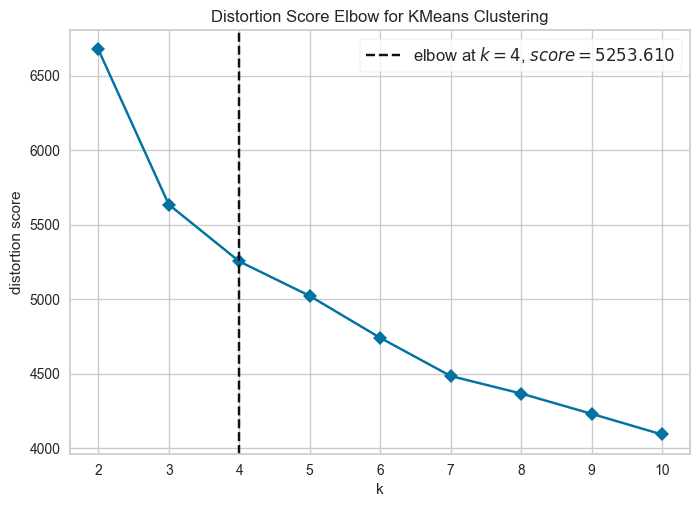

In [12]:
plot_model(kmeans, plot = 'elbow')


In [13]:
plot_model(kmeans, plot = 'silhouette')


TypeError: Plot Type not supported for this model.

<Figure size 800x550 with 0 Axes>

In [14]:
plot_model(kmeans, plot = 'distribution') #to see size of clusters


In [15]:
plot_model(kmeans, plot = 'distribution', feature = 'class')


In [16]:
plot_model(kmeans, plot = 'distribution', feature = 'CaNA_N')


In [17]:
unseen_predictions = predict_model(kmeans, data=data_unseen)
unseen_predictions.head()

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,Behavior,class_t-SC-m,class_c-CS-m,class_t-CS-m,class_c-SC-s,class_c-SC-m,class_t-SC-s,class_c-CS-s,class_t-CS-s,Cluster
0,0.361782,0.565987,0.376145,2.774771,4.450250,0.262906,0.238968,6.041007,0.229808,1.697336,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Cluster 3
1,0.329361,0.503216,0.326145,2.487893,3.925842,0.231177,0.195611,5.337306,0.210556,1.355846,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Cluster 3
2,0.328314,0.500465,0.363265,2.409370,3.796988,0.226250,0.187024,5.330917,0.203198,1.237591,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Cluster 3
3,0.377490,0.528331,0.379560,2.689263,3.978008,0.266753,0.229495,5.441138,0.227684,1.655369,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Cluster 3
4,0.367813,0.478322,0.346371,2.356975,3.561499,0.252121,0.226437,4.868520,0.204288,1.403629,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Cluster 3


In [19]:
save_model(kmeans,'Final Kmeans Model 08Feb2020')


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['DYRK1A_N', 'ITSN1_N', 'BDNF_N',
                                              'NR1_N', 'NR2A_N', 'pAKT_N',
                                              'pBRAF_N', 'pCAMKII_N', 'pCREB_N',
                                              'pELK_N', 'pERK_N', 'pJNK_N',
                                              'PKCA_N', 'pMEK_N', 'pNR1_N',
                                              'pNR2A_N', 'pNR2B_N', 'pPKCAB_N',
                                              'pRSK_N', 'AKT_N', 'BRAF_N',
                                              'CAMKII_N', 'CREB_N', 'ELK_N',
                                              'ERK_N', 'GSK3B_N', 'JNK_N',
                                              'ME...
                                                                          'mapping': Memantine    0
 Saline       1
 NaN         -1
 dtype: int64},
                          

In [20]:
saved_kmeans = load_model('Final Kmeans Model 08Feb2020')


Transformation Pipeline and Model Successfully Loaded


In [21]:
new_prediction = predict_model(saved_kmeans, data=data_unseen)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- MouseID_18899_1
- MouseID_18899_10
- MouseID_18899_11
- MouseID_18899_12
- MouseID_18899_13
- ...


In [23]:
data_unseen.shape

(54, 82)

In [25]:
data_unseen.head

<bound method NDFrame.head of      MouseID  DYRK1A_N   ITSN1_N    BDNF_N     NR1_N    NR2A_N    pAKT_N  \
0     3517_7  0.361782  0.565987  0.376145  2.774771  4.450250  0.262906   
1     3517_8  0.329361  0.503216  0.326145  2.487893  3.925842  0.231177   
2     3517_9  0.328314  0.500465  0.363265  2.409370  3.796988  0.226250   
3    3517_10  0.377490  0.528331  0.379560  2.689263  3.978008  0.266753   
4    3517_11  0.367813  0.478322  0.346371  2.356975  3.561499  0.252121   
5    3517_12  0.296432  0.430919  0.314811  2.175135  3.218595  0.233297   
6    3517_13  0.300902  0.426960  0.395093  2.196560  3.129724  0.239707   
7    3517_14  0.287620  0.402882  0.361793  2.049893  2.749733  0.274013   
8    3517_15  0.282083  0.378520  0.336905  1.870920  2.692749  0.206579   
9     3525_1  0.437860  0.705300  0.417971  2.796769  5.460777  0.279859   
10    3525_2  0.450879  0.735884  0.435057  2.974974  5.829059  0.293795   
11    3525_3  0.441198  0.734952  0.443358  2.978290  6.20